<a href="https://colab.research.google.com/github/MonishaPandhi/IB2AD0_Data_Science_GenerativeAI/blob/main/Copy_of_Linear_regression_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
X = air_quality.data.features

# The dataset metadata indicates no target_col, so we manually select one.
# The problem description mentions 'Ground Truth hourly averaged concentrations for CO, Non Metanic Hydrocarbons, Benzene, Total Nitrogen Oxides (NOx) and Nitrogen Dioxide (NO2)'.
# Let's choose CO(GT) as the target variable.
y = X['CO(GT)']
X = X.drop(columns=['CO(GT)'])

# Drop non-numeric 'Date' and 'Time' columns from X before scaling
X = X.drop(columns=['Date', 'Time'])

# Handle missing values which are tagged as -200 in this dataset
X.replace(-200, np.nan, inplace=True)
y.replace(-200, np.nan, inplace=True)

# Combine X and y temporarily to drop rows with NaN values across both
data_combined_cleaned = pd.concat([X, y], axis=1).dropna()

# Separate X and y again after dropping NaNs
X = data_combined_cleaned.drop(columns=['CO(GT)'])
y = data_combined_cleaned['CO(GT)']

# metadata
print(air_quality.metadata)

# variable information
print(air_quality.variables)

print(f"Shape of X after cleaning: {X.shape}")
print(f"Shape of y after cleaning: {y.shape}")

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [ ]:
# Combine the cleaned X and y into a single DataFrame for presentation
cleaned_data_table = pd.concat([X, y], axis=1)

print("Cleaned Data (first 5 rows):")
display(cleaned_data_table.head())

Cleaned Data (first 5 rows):


,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)
0,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2.6
1,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2.0
2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2.2
3,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2.2
4,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,1.6


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Perform train-test split with 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Initialize and fit the MinMaxScaler on the training features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train_scaled: (661, 12)
Shape of X_test_scaled: (166, 12)
Shape of y_train: (661,)
Shape of y_test: (166,)


I did a train-test split of the data to help build my model. I have checked the test data is only 20% and we have 12 features. To minimise bias, I have used a MinMax scaler.

AI Prompt used:Define the x and y values for the train test split. Do a train test split and use a min max scaler. test data should be 20%

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the scaled training data
linear_reg_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Mean Squared Error (MSE) on Training Data: 0.0487
R-squared (R2) Score on Training Data: 0.9744
Mean Absolute Error (MAE) on Training Data: 0.1621


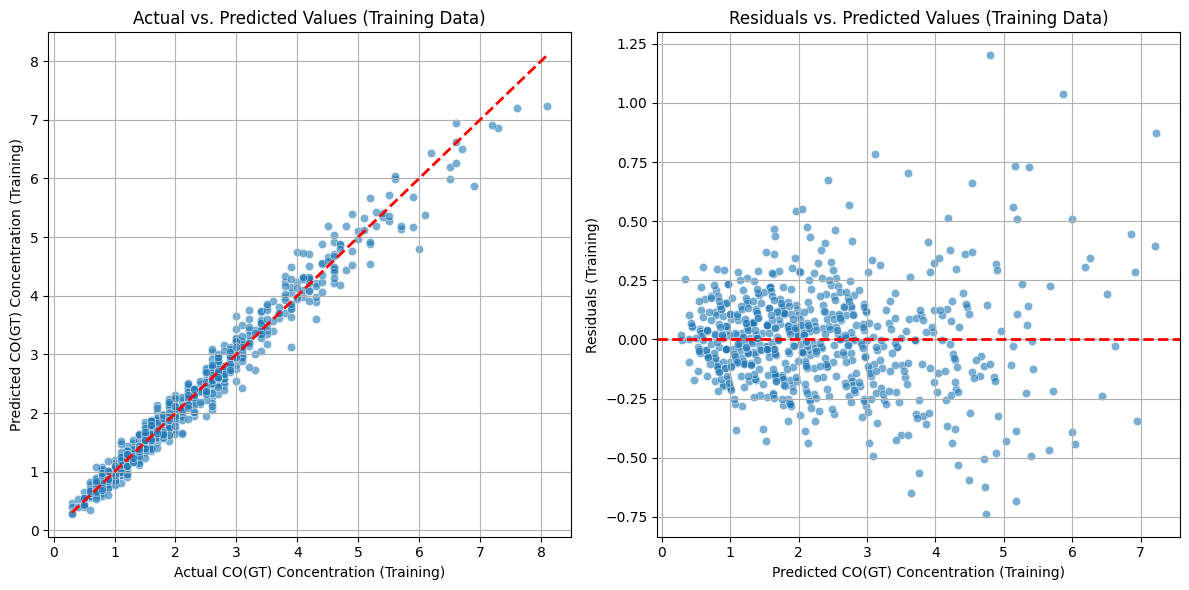

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the scaled training data
y_pred = linear_reg_model.predict(X_train_scaled)

# Calculate evaluation metrics for training data
mse = mean_squared_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)

print(f"Mean Squared Error (MSE) on Training Data: {mse:.4f}")
print(f"R-squared (R2) Score on Training Data: {r2:.4f}")
print(f"Mean Absolute Error (MAE) on Training Data: {mae:.4f}")

# Plotting Actual vs. Predicted values for Training Data
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_pred, alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Actual vs. Predicted Values (Training Data)')
plt.xlabel('Actual CO(GT) Concentration (Training)')
plt.ylabel('Predicted CO(GT) Concentration (Training)')
plt.grid(True)

# Plotting Residuals for Training Data
residuals = y_train - y_pred
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residuals vs. Predicted Values (Training Data)')
plt.xlabel('Predicted CO(GT) Concentration (Training)')
plt.ylabel('Residuals (Training)')
plt.grid(True)

plt.tight_layout()
plt.show()

I have built a linear regression model to run on the training data as air quality is numeric and continous. Hence, we can map out a linear relationship. I have calculated the mean squared error, mean absolute error and r^2 score to assess the accuracy. The r^2 score is incredibly close to 1 suggesting the predicted values of CO (GT) concentration are quite close to the actual values. Hence, this is a comprehensive and simple model. The scatterplot visually shows this as some points are close to the line of best fit. However, the residuals aren't very close to the line of best fit suggesting there are areas for improvement.

AI prompt used: calculate the mean squared error, r^2 value and mean absolute error of the model. also plot it visually.

Lasso Regression model trained successfully.

Lasso Regression Metrics:
Mean Squared Error (MSE): 0.0815
R-squared (R2) Score: 0.9646
Mean Absolute Error (MAE): 0.2024


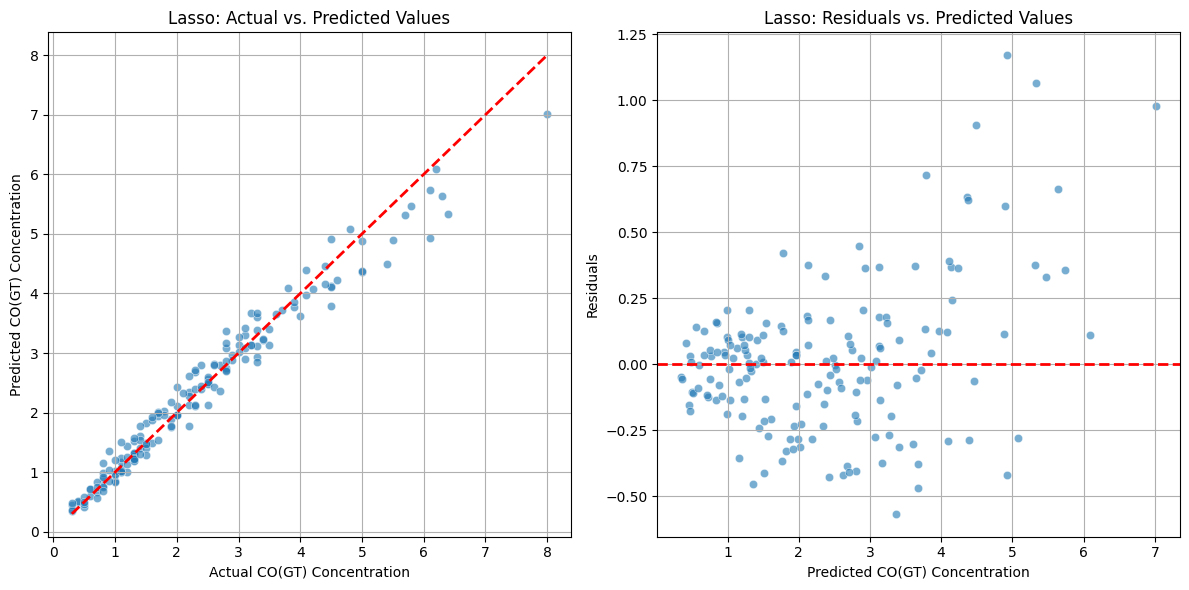

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Lasso Regression model
# You might want to tune the 'alpha' parameter for better performance.
lasso_model = Lasso(alpha=0.01, random_state=100) # Start with a small alpha value

# Train the Lasso model using the scaled training data
lasso_model.fit(X_train_scaled, y_train)

print("Lasso Regression model trained successfully.")

# Make predictions on the scaled test data
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate evaluation metrics for Lasso
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"\nLasso Regression Metrics:")
print(f"Mean Squared Error (MSE): {mse_lasso:.4f}")
print(f"R-squared (R2) Score: {r2_lasso:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lasso:.4f}")

# Plotting Actual vs. Predicted values for Lasso
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Lasso: Actual vs. Predicted Values')
plt.xlabel('Actual CO(GT) Concentration')
plt.ylabel('Predicted CO(GT) Concentration')
plt.grid(True)

# Plotting Residuals for Lasso
residuals_lasso = y_test - y_pred_lasso
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_lasso, y=residuals_lasso, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Lasso: Residuals vs. Predicted Values')
plt.xlabel('Predicted CO(GT) Concentration')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

Best alpha found: 0.0001
Optimized Lasso Regression model trained successfully.

Optimized Lasso Regression Metrics:
Mean Squared Error (MSE): 0.0549
R-squared (R2) Score: 0.9762
Mean Absolute Error (MAE): 0.1754


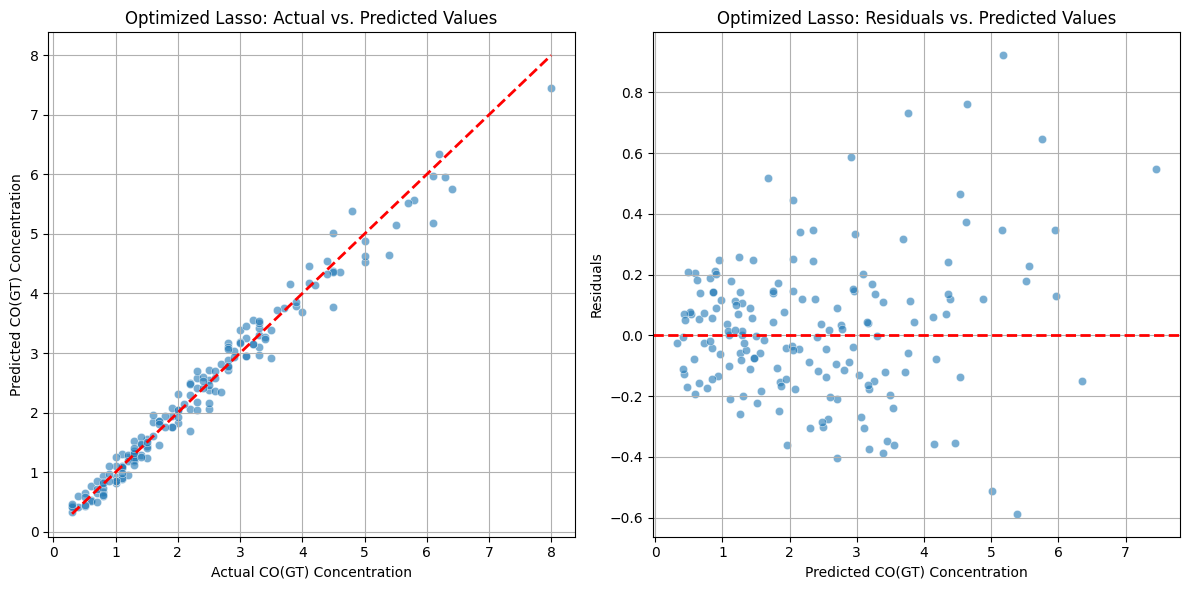

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Define a range of alpha values to search
param_grid = {'alpha': np.logspace(-4, 0, 50)} # Search alpha from 0.0001 to 1

# Initialize Lasso Regression model
lasso = Lasso(random_state=100)

# Initialize GridSearchCV
# Using negative mean squared error as scoring to maximize performance (lower MSE is better)
grid_search_lasso = GridSearchCV(lasso, param_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit GridSearchCV to find the best alpha
grid_search_lasso.fit(X_train_scaled, y_train)

# Get the best alpha parameter
best_alpha = grid_search_lasso.best_params_['alpha']
print(f"Best alpha found: {best_alpha:.4f}")

# Train a new Lasso model with the best alpha
optimized_lasso_model = Lasso(alpha=best_alpha, random_state=100)
optimized_lasso_model.fit(X_train_scaled, y_train)

print("Optimized Lasso Regression model trained successfully.")

# Make predictions with the optimized model
y_pred_optimized_lasso = optimized_lasso_model.predict(X_test_scaled)

# Calculate evaluation metrics for optimized Lasso
mse_optimized_lasso = mean_squared_error(y_test, y_pred_optimized_lasso)
r2_optimized_lasso = r2_score(y_test, y_pred_optimized_lasso)
mae_optimized_lasso = mean_absolute_error(y_test, y_pred_optimized_lasso)

print(f"\nOptimized Lasso Regression Metrics:")
print(f"Mean Squared Error (MSE): {mse_optimized_lasso:.4f}")
print(f"R-squared (R2) Score: {r2_optimized_lasso:.4f}")
print(f"Mean Absolute Error (MAE): {mae_optimized_lasso:.4f}")

# Plotting Actual vs. Predicted values for Optimized Lasso
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_optimized_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Optimized Lasso: Actual vs. Predicted Values')
plt.xlabel('Actual CO(GT) Concentration')
plt.ylabel('Predicted CO(GT) Concentration')
plt.grid(True)

# Plotting Residuals for Optimized Lasso
residuals_optimized_lasso = y_test - y_pred_optimized_lasso
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_optimized_lasso, y=residuals_optimized_lasso, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Optimized Lasso: Residuals vs. Predicted Values')
plt.xlabel('Predicted CO(GT) Concentration')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

After using L1 regularisation and tuning the alpha parameter in attempts to improve the accuracy of the model, the different scores didn't change by very much.

AI prompt used: Conduct lasso regression on the model to improve the accuracy. calculate the relevant accuracy scores and visually plot it. Tune the alpha parameter for Lasso Regression


K-Fold Cross-Validation Results (5 folds) for Optimized Lasso Regression:
Mean Squared Error (MSE): 0.0523 (+/- 0.0086)
R-squared (R2) Score: 0.9726 (+/- 0.0017)
Mean Absolute Error (MAE): 0.1661 (+/- 0.0142)


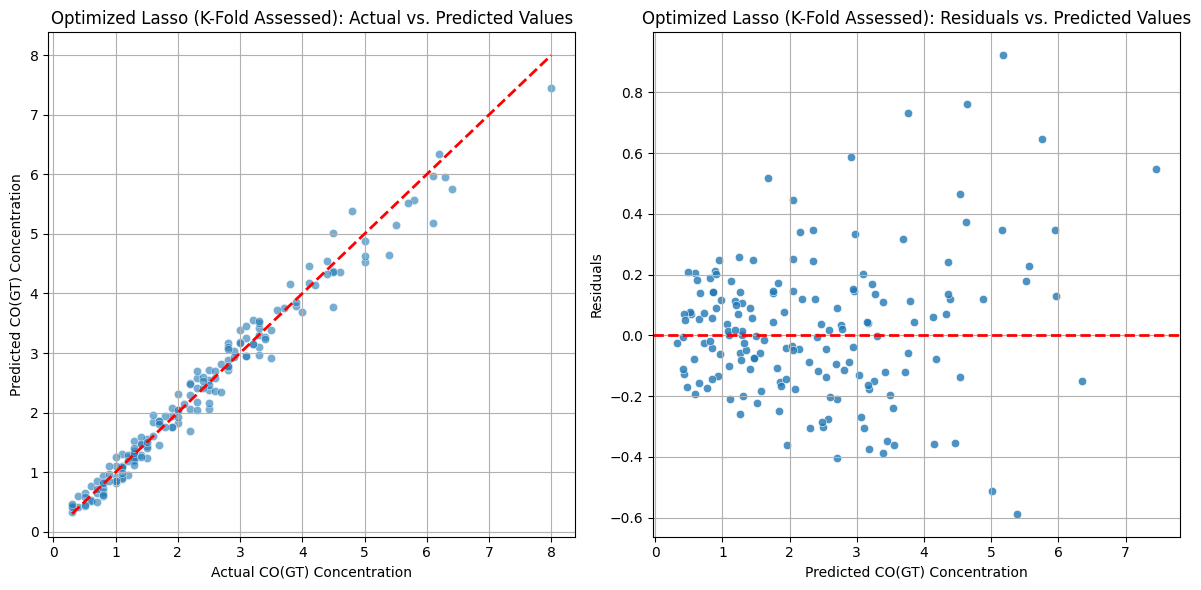

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Lasso
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Define the number of splits for K-fold cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=100)

# Re-initialize the optimized Lasso model (or use the one already trained if preferred)
# We use the best_alpha found previously
model_for_cv = Lasso(alpha=best_alpha, random_state=100)

# Define scorers for cross-validation
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Perform K-fold cross-validation for MSE
mse_scores = cross_val_score(model_for_cv, X_train_scaled, y_train, cv=kf, scoring=mse_scorer)
# Perform K-fold cross-validation for R-squared
r2_scores = cross_val_score(model_for_cv, X_train_scaled, y_train, cv=kf, scoring=r2_scorer)
# Perform K-fold cross-validation for MAE
mae_scores = cross_val_score(model_for_cv, X_train_scaled, y_train, cv=kf, scoring=mae_scorer)

print(f"\nK-Fold Cross-Validation Results ({n_splits} folds) for Optimized Lasso Regression:")
print(f"Mean Squared Error (MSE): {-mse_scores.mean():.4f} (+/- {mse_scores.std():.4f})")
print(f"R-squared (R2) Score: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
print(f"Mean Absolute Error (MAE): {-mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")

# For visual plotting, we'll use the predictions from the optimized_lasso_model (already trained on full X_train_scaled)
# Make predictions with the optimized model
y_pred_optimized_lasso = optimized_lasso_model.predict(X_test_scaled)

# Plotting Actual vs. Predicted values for Optimized Lasso (after CV assessment)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_optimized_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Optimized Lasso (K-Fold Assessed): Actual vs. Predicted Values')
plt.xlabel('Actual CO(GT) Concentration')
plt.ylabel('Predicted CO(GT) Concentration')
plt.grid(True)

# Plotting Residuals for Optimized Lasso (after CV assessment)
residuals_optimized_lasso = y_test - y_pred_optimized_lasso
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_optimized_lasso, y=residuals_optimized_lasso, alpha=0.8)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Optimized Lasso (K-Fold Assessed): Residuals vs. Predicted Values')
plt.xlabel('Predicted CO(GT) Concentration')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

Using K-fold cross validation works by creating 'k' chunks of the training data and then training the model 'k' times. Accuracy levels did not change much.  

AI prompts used: Use k fold cross validation to improve the accuracy of the model. calculate the relevant accuracy scores then visually plot it

Mean Squared Error (MSE) on Test Data: 0.0551
R-squared (R2) Score on Test Data: 0.9761
Mean Absolute Error (MAE) on Test Data: 0.1758


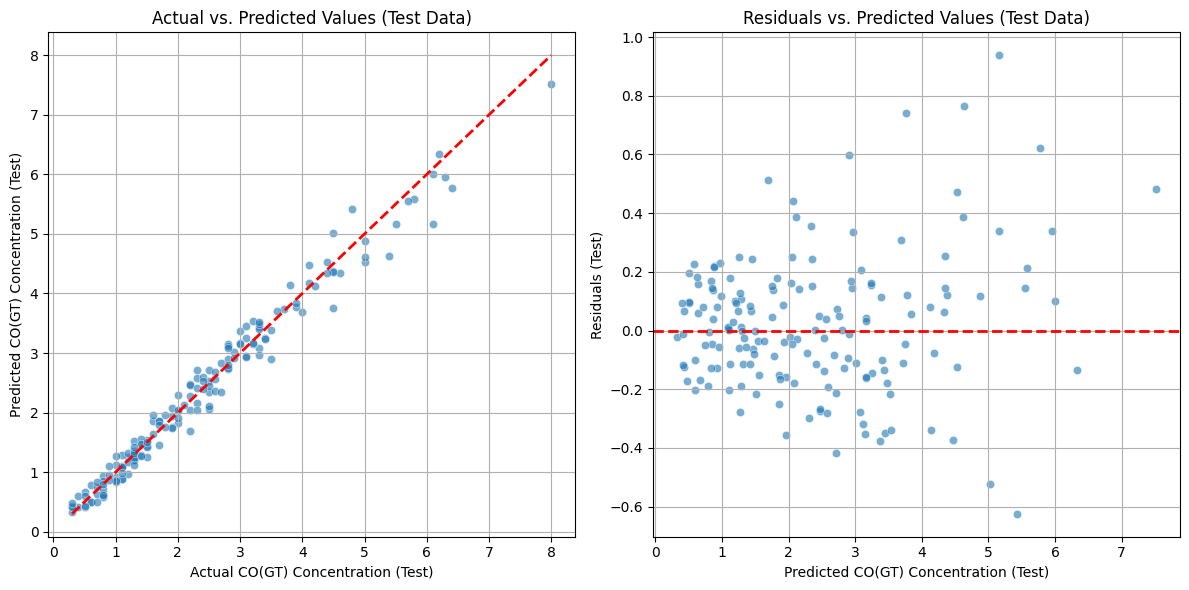

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the scaled test data
y_pred_test = linear_reg_model.predict(X_test_scaled)

# Calculate evaluation metrics for test data
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Mean Squared Error (MSE) on Test Data: {mse_test:.4f}")
print(f"R-squared (R2) Score on Test Data: {r2_test:.4f}")
print(f"Mean Absolute Error (MAE) on Test Data: {mae_test:.4f}")

# Plotting Actual vs. Predicted values for Test Data
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Actual vs. Predicted Values (Test Data)')
plt.xlabel('Actual CO(GT) Concentration (Test)')
plt.ylabel('Predicted CO(GT) Concentration (Test)')
plt.grid(True)

# Plotting Residuals for Test Data
residuals_test = y_test - y_pred_test
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_test, y=residuals_test, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residuals vs. Predicted Values (Test Data)')
plt.xlabel('Predicted CO(GT) Concentration (Test)')
plt.ylabel('Residuals (Test)')
plt.grid(True)

plt.tight_layout()
plt.show()

The MSE and MAE on the data is very low suggesting the model's predicted CO(GT) concentrations and the actual concentrations is small. The R^2 model is high suggesting the variable in actual CO (GT) concentration can be well explained by my model's features. However, in certain instances there are subtle patterns of errors hence under or over-predicting at certain concentration levels. This would have to be further checked with a subject matter expert.

AI prompt used: run the linear regression model on the test data in a separate cell. work out the relevant accuracy scores and visually plot it